# MI

# Labor

# Regressziós modellek - Lineáris regresszió

___
**Regressziós modell készítése egy fiktív példán keresztül**

A szomszédunk ingatlanügynök, és segítségre van szüksége a lakásárak előrejelzésében. Készítsünk egy modellt számára, amely lehetővé teszi, hogy korábban eladott lakások jellemzői alapján becslést adjon arról, hogy melyik lakást érdemes eladni.

Mindehhez a szomszédunk összegyűjtött egy csomó adatot a korábbi értékesítések alapján, amely az `USA_Housing.csv` fájlban található.

Az adatok a következő jellemzőket tartalmazzák:

* 'Avg. Area Income': az azonos városban lakók átlagos jövedelme.
* 'Avg. Area House Age': az azonos városban levő lakások átlagos kora.
* 'Avg. Area Number of Rooms': az azonos városban levő lakások átlagos szobaszáma.
* 'Avg. Area Number of Bedrooms': az azonos városban levő lakások átlagos hálószobaszáma.
* 'Area Population': a város népessége, ahol a lakás található.
* 'Price': az ár, amelyen a lakás eladásra került.
* 'Address': az eladott ház címe.

Az adathalmaz: [USA Housing](https://www.kaggle.com/gopalchettri/usa-housing)

___
## Az adatok vizsgálata

### A szükséges könyvtárak importálása

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Az adatok beolvasása dataframe-ként

In [3]:
#houses néven dataframe készítése az USA_Housing.cvs fájlból
houses = pd.read_csv("USA_Housing.csv")

In [8]:
#a dataframe áttekintése (head, info, describe, shape)
houses.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Avg. Area Income,5000.0,6.858311e+04,10657.991214,17796.631190,61480.562388,6.880429e+04,7.578334e+04,1.077017e+05
Avg. Area House Age,5000.0,5.977222e+00,0.991456,2.644304,5.322283,5.970429e+00,6.650808e+00,9.519088e+00
Avg. Area Number of Rooms,5000.0,6.987792e+00,1.005833,3.236194,6.299250,7.002902e+00,7.665871e+00,1.075959e+01
Avg. Area Number of Bedrooms,5000.0,3.981330e+00,1.234137,2.000000,3.140000,4.050000e+00,4.490000e+00,6.500000e+00
Area Population,5000.0,3.616352e+04,9925.650114,172.610686,29403.928702,3.619941e+04,4.286129e+04,6.962171e+04
Price,5000.0,1.232073e+06,353117.626581,15938.657923,997577.135049,1.232669e+06,1.471210e+06,2.469066e+06


___
## Feltáró adatelemzés

Az adatok előzetes elemzéséhez készítünk néhány diagramot

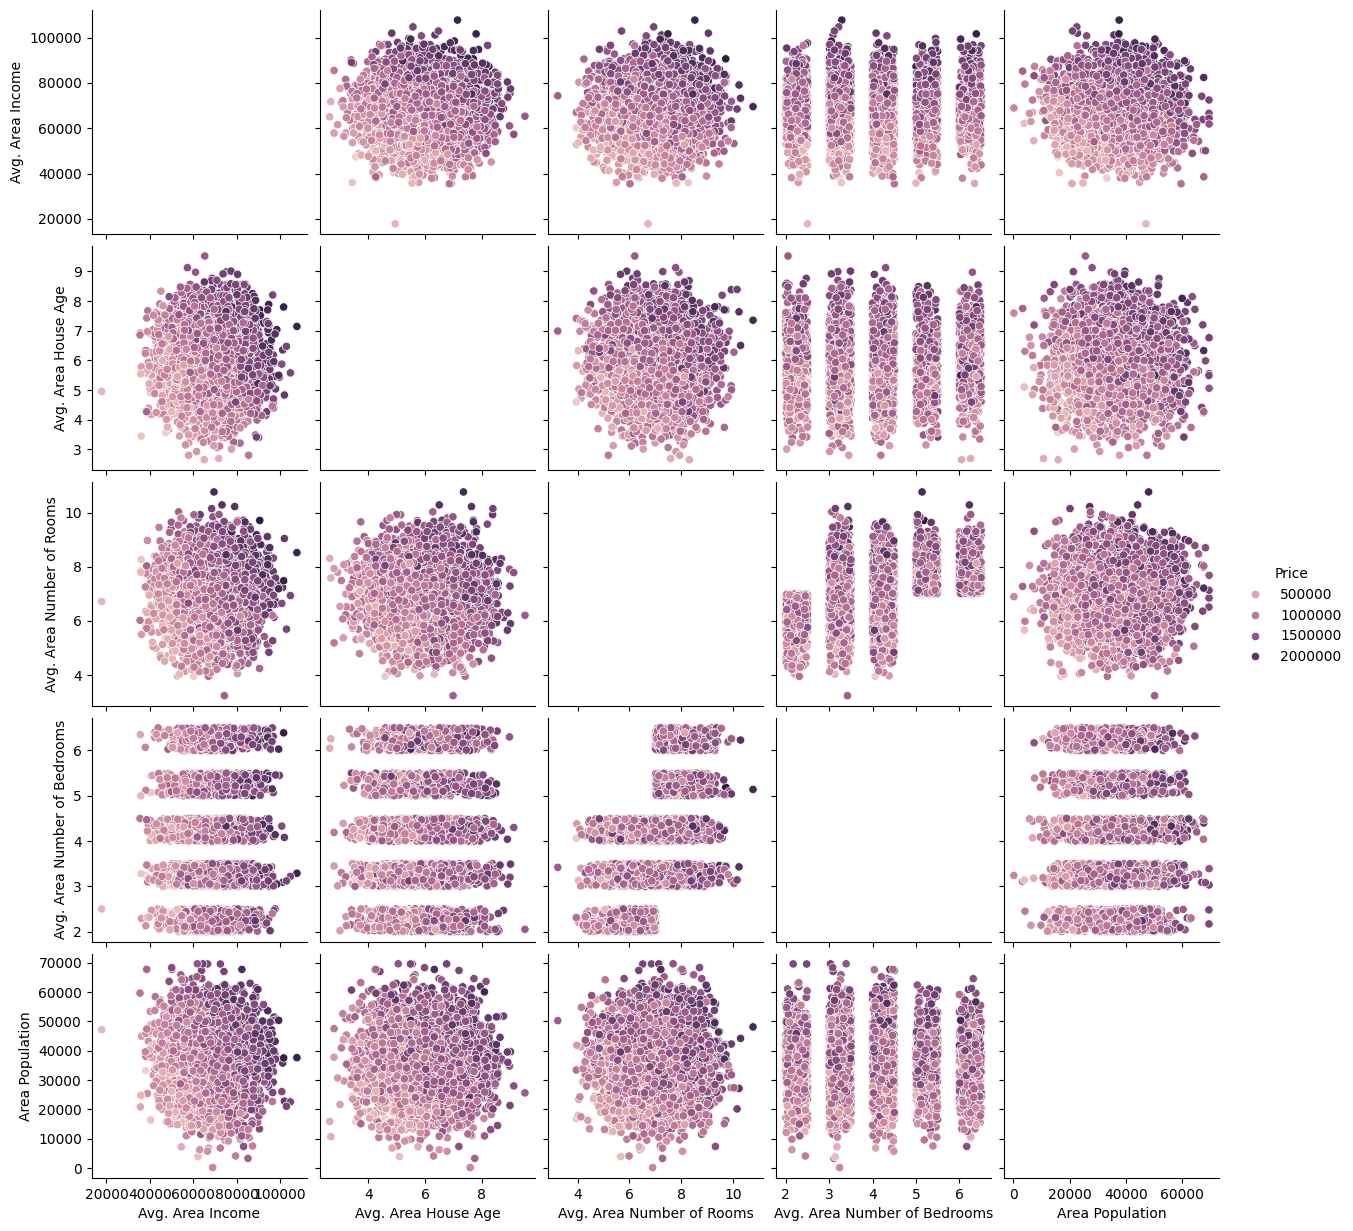

In [9]:
#pontdiagram mátrix (pairplot)
sns.pairplot(houses,hue="Price")

In [ ]:
#hisztogram az ár ('Price') eloszlásáról


In [10]:
#korreláció megjelenítése hőtérképen (melyek az árral leginkább korreláló tulajdonságok?)
sns.heatmap(houses)

ValueError: could not convert string to float: '208 Michael Ferry Apt. 674\nLaurabury, NE 37010-5101'

____
# Lineáris regressziós modell tanítása

A regressziós modell tanításához először fel kell osztanunk adatainkat a tulajdonságokra (`X`) és a cél attribútumra (`y` - esetünkben ez a `Price` oszlop).

In [11]:
houses.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='str')

In [ ]:
#X és y dataframe-ek létrehozása


## Tanulóhalmaz és teszthalmaz készítése

In [15]:
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
#adathalmaz kettévágása, teszhalmaz mérete: 30%, random_state=101


## A modell tanítása

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
#LinearRegression példányosítása model néven


In [ ]:
#a modell illesztése a tanulási halmazra


In [ ]:
#esetlegesen felmerült probléma megoldása


## A modell értékelése

Értékeljük a modellt az együtthatóinak áttekintésével és azok értelmezésével.

[Linear Models](https://scikit-learn.org/stable/modules/linear_model.html)

In [ ]:
# Metszéspont (intercept_)


In [ ]:
# Együtthatók (coef_)


In [ ]:
# Együtthatók (coef_) megjelenítése dataframe-ként
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Együtthatók'])
coeff_df

### Az együtthatók értelmezése:

* Egy egységnyi **Avg. Area Income növelés** (a többi jellemzőt nem változtatva) **21.62 USD árnövekedéssel jár**.
* Egy egységnyi  **Avg. Area House Age növelés** (a többi jellemzőt nem változtatva) **165221.12 USD árnövekedéssel jár**.
* Egy egységnyi  **Avg. Area Number of Rooms növelés** (a többi jellemzőt nem változtatva) **121405.38 USD árnövekedéssel jár**.
* Egy egységnyi  **Avg. Area Number of Bedrooms növelés** (a többi jellemzőt nem változtatva) **1318.72 USD árnövekedéssel jár**.
* Egy egységnyi  **Area Population növelés** (a többi jellemzőt nem változtatva) **15.23 USD árnövekedéssel jár**.


## Becslés (prediction) a modell alapján

Nézzük meg a teszhalmazon végzett becslést és vizsgáljuk meg, hogy mennyire jó a modell.

In [ ]:
#becslés a teszthalmazon predictions néven


In [ ]:
#dataframe készítése a becsült (Predict) és a valós (Price) értékekkel
test_df = pd.DataFrame(y_test,columns=['Price'])
predict_df = pd.DataFrame(predictions,columns=['Predict'],index=test_df.index)
result_df = pd.concat([test_df,predict_df],axis=1)
result_df.head()

In [ ]:
#becsült és valós értékek megjelenítése pontdiagrammal (scatterplot)


### Hiba eloszlásának megjelenítése histogrammal

In [ ]:
#histplot


## Regresszió értékelési mutatók


A regressziós feladatok három általánosan használt értékelési mutatója:

**Mean Absolute Error** (MAE) az eltérések abszolút értékének átlaga:

$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

**Mean Squared Error** (MSE) az eltérések négyzetének átlaga:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Root Mean Squared Error** (RMSE) a négyzetes hibák átlagának négyzetgyöke:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

A mutatók összehasonlítása:

- **MAE** a legkönnyebben érthető, mert ez az átlagos hiba.
- **MSE** népszerűbb, mint a MAE, mert az MSE "bünteti" a nagyobb hibákat.
- **RMSE** népszerűbb, mint az MSE, mert az RMSE értelmezhető "y" egységekben.

Mindegyik **veszteségfüggvény**, amelyet minimalizálunk.

In [ ]:
from sklearn import metrics

In [ ]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

___
___
# Regressziós modellek - Logisztikus regresszió


**Logisztikus regressziós modell készítése egy fiktív példán keresztül**

Egy online reklám adathalmazzal dolgozunk, amely tartalmazza, hogy egy adott internet-felhasználó rákattintott-e a cég weboldalán egy hirdetésre.

Feladat: egy osztályozó modell készítése, amely megjósolja, hogy a felhasználó jellemzői alapján várhatóan rákattint-e majd egy adott újabb hirdetésre.

Az adathalmaz, amely az `advertising.csv` fájlban található, a következő jellemzőket tartalmazza:

* 'Daily Time Spent on Site': a felhasználó adott honlapon töltött ideje percben, naponta
* 'Age': a felhasználó kora években
* 'Area Income': az adott városban az átlagos jövedelem
* 'Daily Internet Usage': a felhasználó interneten töltött ideje percben, naponta
* 'Ad Topic Line': a hirdetés címe
* 'City': a felhasználó lakhelye, város
* 'Male': a felhasználó neme, férfi-e
* 'Country': a felhasználó lakhelye, ország
* 'Timestamp': időbélyeg, amikor a felhasználó rákattintott a hirdetésre vagy bezárta az ablakot
* 'Clicked on Ad': hirdetésre kattintás jelölése: 0 vagy 1

[Logisztikus regresszió](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)

___
## Az adatok vizsgálata

### A szükséges könyvtárak importálása

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Az adatok beolvasása dataframe-ként

In [ ]:
#advertising.csv fájl beolvasása ad_data néven


In [ ]:
#dataframe áttekintése


___
## Feltáró adatelemzés

Az adatok előzetes elemzéséhez készítünk néhány diagramot.

In [ ]:
#Age attribútum eloszlásának megjelenítése (histplot)


In [ ]:
#pontdiagram mátrix (pairplot) készítése a 'Clicked on Ad' attribútum szerint elkülönítve


In [ ]:
#pontdiagram (jointplot) készítése az 'Age' és 'Area Income' attribútumokkal, a 'Clicked on Ad' attribútum szerint elkülönítve


In [ ]:
#pontdiagram (jointplot) készítése az 'Age' és 'Daily Time Spent on Site' attribútumokkal, a 'Clicked on Ad' attribútum szerint elkülönítve


In [ ]:
#pontdiagram (jointplot) készítése a 'Daily Time Spent on Site' és 'Daily Internet Usage' attribútumokkal, a 'Clicked on Ad' attribútum szerint elkülönítve


# Logisztikus Regressziós modell

## Tanulóhalmaz és teszthalmaz

Gondoljuk át, hogy mely paramétereket célszerű kiválasztani a modell készítéséhez.

In [ ]:
#train_test_split importálása
#tanulóhalmaz és teszthalmaz (mérete 30%) készítése, random_state=1234


## A modell tanítása

In [ ]:
#LogisticRegression modell importálása a linear_model családból
#példányosítás logmodel néven
#modell tanítása


## Predikció és kiértékelés

In [ ]:
#becslés a modellel predictions névvel, a becslés kiiratása


### Keveredési mátrix (confusion matrix)

In [ ]:
#importálás és a keveredési mátrix elkészítése


In [ ]:
#keveresési mártix megjelenítése ConfusionMatrixDisplay használatával
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logmodel.classes_).plot();

### ROC görbe

In [ ]:
from sklearn.metrics import RocCurveDisplay

In [ ]:
RocCurveDisplay.from_estimator(logmodel, X_test, y_test);

### Classification report

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test,predictions))